**Unsupervised Learning
Finding Hidden Groups**

What is Unsupervised Learning?

In supervised learning you have a label (the answer) for every row of training data. In unsupervised learning there are
no labels — the algorithm must discover structure, patterns, and groups entirely on its own.

Supervised Learning vs Unsupervised Learning

| Feature                 | Supervised Learning                                                         | Unsupervised Learning                                                            |
| ----------------------- | --------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Labels**              | Requires labeled data (target column available)                             | No labels required (no target column)                                            |
| **Goal**                | Learn from known answers and make predictions                               | Discover hidden patterns, groups, or relationships                               |
| **Input Data**          | Features + Target (X and y)                                                 | Features only (X)                                                                |
| **Output**              | Predicted class or numerical value                                          | Clusters, components, associations, anomalies                                    |
| **Common Algorithms**   | Logistic Regression, Linear Regression, Decision Tree, Random Forest   | K-Means, PCA, DBSCAN, Hierarchical Clustering, Autoencoders                      |
| **Evaluation Metrics**  | Accuracy, Precision, Recall, F1-Score, ROC-AUC, RMSE                        | Silhouette Score, Elbow Method, Cluster Visualization                            |
| **Teacher Present?**    |  Yes (correct answers available)                                           |  No (model learns on its own)                                                   |
| **Typical Questions**   | "Will this customer buy?" "Is this email spam?"                             | "Can customers be grouped?" "Are there hidden patterns?"                         |
| **Real-World Examples** | Spam Detection, Disease Prediction, House Price Prediction, Fraud Detection | Customer Segmentation, Market Basket Analysis, Topic Modeling, Anomaly Detection |


Few example where we can use non supervised learning.

Imagine you are given a large dataset, but there are no answers, labels, or target column provided.

For example:

A shopping website has data about 1 lakh customers.

A news website has 10,000 articles.

A bank has millions of transactions.

Nobody tells us:

Which customer belongs to which group.

Which articles belong to which topic.

Which transactions are fraudulent.

The goal is to let the machine discover hidden patterns automatically.

This is called Unsupervised Learning.

Supervised vs Unsupervised Side by Side

See the difference in how you set up each type of problem:

In [1]:
# ■■ Supervised vs Unsupervised Comparison ■■
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


# Generate toy data: 300 points, 3 natural clusters
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42)



# X → feature matrix (coordinates)
# y_true → the TRUE labels (we'd have these in supervised learning)
# ■■ Supervised approach: pretend we have labels ■■
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


X_tr,X_te,y_tr,y_te = train_test_split(
    X, y_true, test_size=0.2, random_state=42)

clf = LogisticRegression().fit(X_tr, y_tr)

print(f'Supervised accuracy: {clf.score(X_te,y_te):.2%}') # Uses labels

Supervised accuracy: 100.00%


In [2]:
# ■■ Unsupervised approach: NO labels used at all ■■
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X) # No y passed — only X!

print('Cluster assignments (first 10):', cluster_labels[:10])
# [0, 2, 1, 0, 2, ...] — but 0,1,2 are just cluster IDs, not class names

Cluster assignments (first 10): [1 1 0 2 1 2 0 2 0 0]


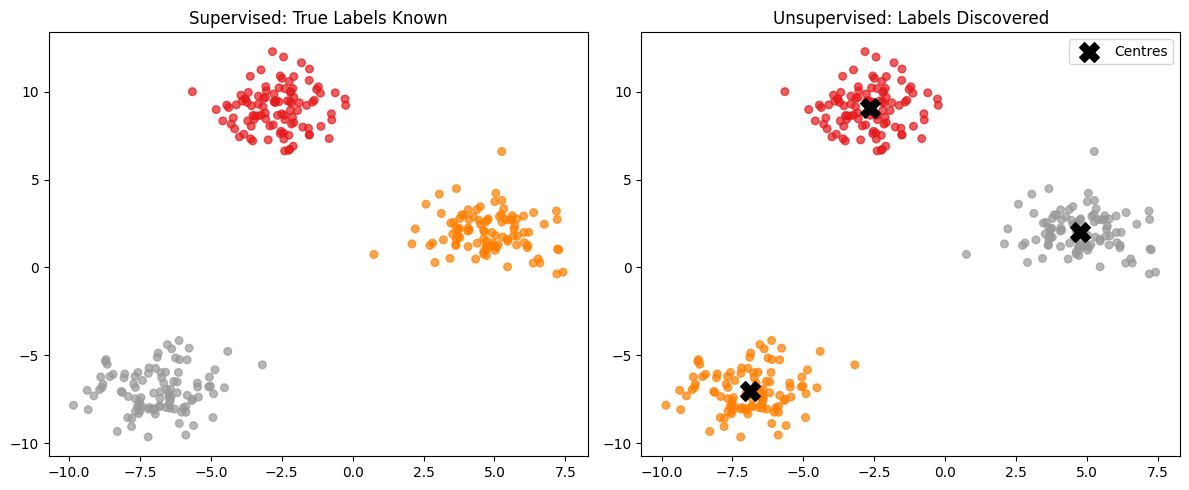

In [3]:
# ■■ Plot both side by side ■■
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X[:,0], X[:,1], c=y_true, cmap='Set1', s=30, alpha=0.7)
ax1.set_title('Supervised: True Labels Known', fontsize=12)
ax2.scatter(X[:,0], X[:,1], c=cluster_labels, cmap='Set1', s=30, alpha=0.7)
ax2.scatter(*kmeans.cluster_centers_.T, c='black', s=200, marker='X', label='Centres')
ax2.set_title('Unsupervised: Labels Discovered', fontsize=12)
ax2.legend(); plt.tight_layout(); plt.show()
# The colours may differ but the shapes should match!

K-Means Clustering Algorithm

K-Means is the most popular clustering algorithm. Think of it as organising a messy drawer: you pick K spots to put
dividers, assign every item to its nearest divider, then slide each divider to the middle of its group. Repeat until nothing
moves.

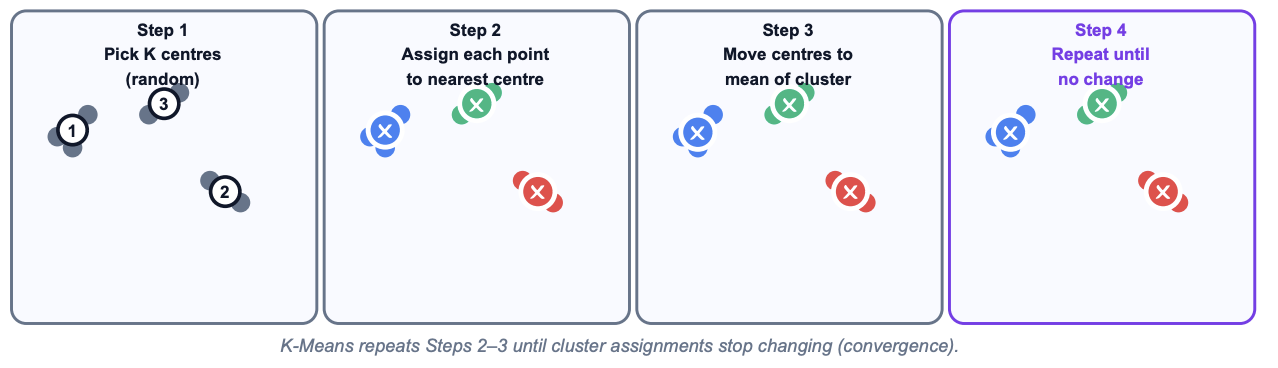

The 4-Step Algorithm

K-Means is an unsupervised learning algorithm that groups similar data points into K clusters.

The algorithm repeatedly performs Assign → Update → Repeat until the clusters stop changing.

| Step              | What Happens                                                          | Simple Explanation                                                               |
| ----------------- | --------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| **1. Initialize** | Randomly place K cluster centers (centroids) in the data space        | Pick K starting points randomly. These act as temporary cluster centers.         |
| **2. Assign**     | Each data point goes to its nearest centroid                          | Every point joins the cluster whose center is closest to it.                     |
| **3. Update**     | Move each centroid to the mean of all points assigned to that cluster | Recalculate the center of each cluster using the average position of its points. |
| **4. Repeat**     | Repeat Assign → Update until clusters stop changing                   | Continue adjusting clusters until the assignments become stable.                 |


MATHEMATICAL VIEW

| Step            | Formula                                                     |
| --------------- | ----------------------------------------------------------- |
| **Initialize**  | Centroids = randomly choose K points from the dataset       |
| **Assign**      | Each point is assigned to the nearest centroid              |
| **Update**      | New centroid = average (mean) of all points in that cluster |
| **Convergence** | Stop when cluster assignments no longer change              |


K-MEANS LIMITATIONS

| Limitation                            | Explanation                                                                                                                                   | Solution                                                                                                 |
| ------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| **1. Need to Choose K in Advance**    | K-Means requires you to specify the number of clusters (**K**) before training. The algorithm does not know the correct number automatically. | Use the **Elbow Method** to find a suitable value of K.                                                  |
| **2. Sensitive to Initial Centroids** | Since centroids are chosen randomly at the beginning, different starting points can produce different clusters and results.                   | Use **n_init=10** (or higher) so the algorithm tries multiple random starts and keeps the best solution. |
| **3. Assumes Spherical Clusters**     | K-Means works best when clusters are roughly circular (2D) or spherical (multi-dimensional) and have similar sizes.                           | For irregular or elongated clusters, consider algorithms like **DBSCAN** or **Hierarchical Clustering**. |


K-Means Step by Step with Animation-Style Output

Build K-Means from scratch first, then use sklearn's version:

In [4]:
# ■■ K-Means: Manual + sklearn ■■
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
# ■■ Part 1: Manual K-Means ■■
def manual_kmeans(X, k=3, max_iter=10, seed=42):
  rng = np.random.default_rng(seed)
# Step 1: random initial centres
  centres = X[rng.choice(len(X), k, replace=False)]
  print(centres)
  for iteration in range(max_iter):
# Step 2: Assign each point to nearest centre
    dists = np.linalg.norm(X[:, np.newaxis] - centres, axis=2) # (n, k)
    labels = np.argmin(dists, axis=1) # (n,)
# Step 3: Move centres to mean of their cluster
    new_centres = np.array([X[labels == k_].mean(axis=0) for k_ in range(k)])
    print(f'Iter {iteration+1}: centre moved by {np.linalg.norm(new_centres-centres):.4f}')
    if np.allclose(centres, new_centres): print(' → Converged!'); break
    centres = new_centres
  return labels, centres
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)
labels, centres = manual_kmeans(X, k=3)

[[ 5.5938806   2.62456094]
 [-7.70184759 -6.63642238]
 [ 3.86705362  1.73635108]]
Iter 1: centre moved by 6.2785
Iter 2: centre moved by 3.6678
Iter 3: centre moved by 0.0000
 → Converged!


In [6]:
# ■■ Part 2: sklearn KMeans (the production version) ■■
scaler = StandardScaler() # Standardise BEFORE clustering
X_scaled = scaler.fit_transform(X) # K-Means uses distances → scale matters!
km = KMeans(
n_clusters=3, # K — number of clusters
init='k-means++', # Smart initialisation (better than random)
n_init=10, # Run 10 times with different starts, keep best
max_iter=300, # Max iterations per run
random_state=42
)
km.fit(X_scaled)
print(f'Inertia : {km.inertia_:.2f}') # Total within-cluster variance
print(f'Iterations : {km.n_iter_}') # How many loops it took
print(f'Cluster sizes: {np.bincount(km.labels_)}') # e.g. [67 66 67]

Inertia : 12.18
Iterations : 2
Cluster sizes: [67 66 67]


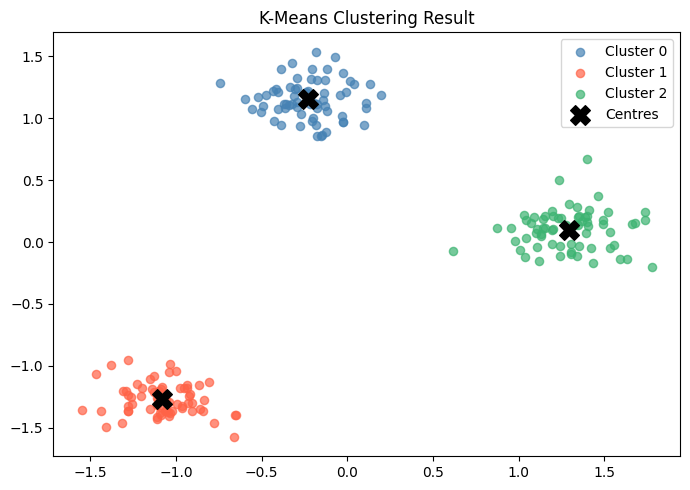

In [7]:
# ■■ Visualise the result ■■
plt.figure(figsize=(7,5))
colours = ['steelblue','tomato','mediumseagreen']
for k in range(3):
  mask = km.labels_ == k
  plt.scatter(X_scaled[mask,0], X_scaled[mask,1],
    c=colours[k], s=35, alpha=0.7, label=f'Cluster {k}')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
    c='black', s=200, marker='X', zorder=5, label='Centres')
plt.title('K-Means Clustering Result'); plt.legend(); plt.tight_layout(); plt.show()

Elbow Method — Finding the Right K

The Elbow Method helps determine the optimal number of clusters (K) by finding the point where increasing K no longer significantly reduces WCSS(Within in cluster sum of squares).

How do we know the right value of K?

The Elbow Method runs K-Means multiple times using different values of K:

K = 1, 2, 3, 4, 5, ...

For each value of K, we calculate Inertia (WCSS).

**What is Inertia?**

Inertia measures:

"How close the data points are to their cluster center."

Lower Inertia → Better clustering
Higher Inertia → Poor clustering

WCSS (Within-Cluster Sum of Squares)

WCSS is one of the most important concepts in K-Means Clustering.



How close the data points are to the center (centroid) of their cluster.

It calculates the total squared distance between each data point and its cluster centroid.

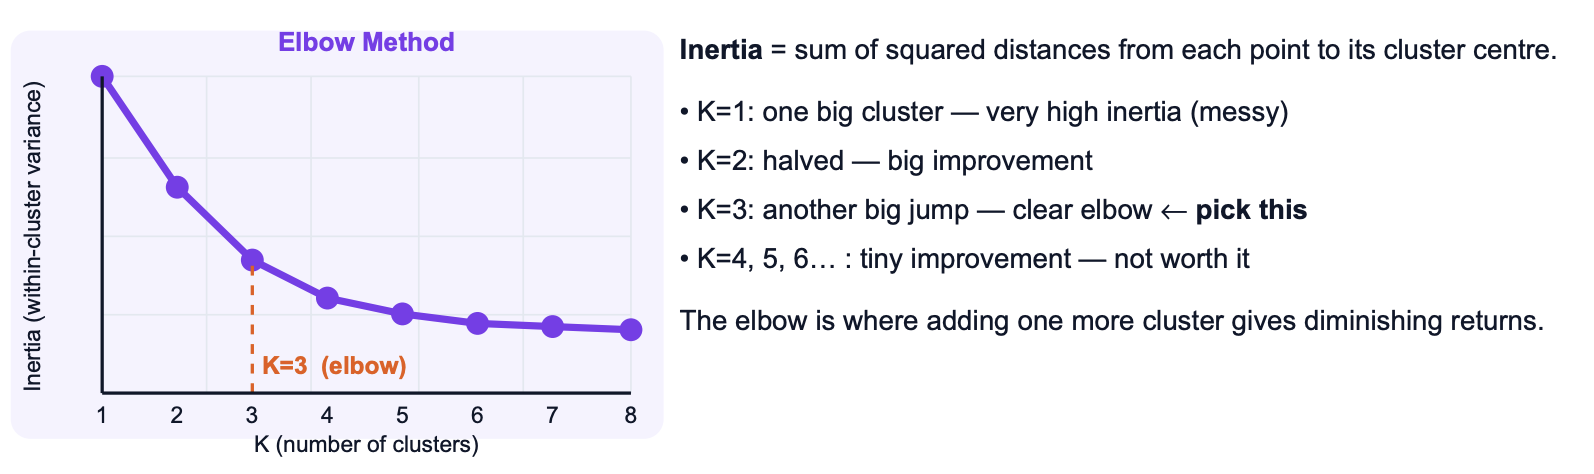

Elbow Method + Silhouette Score (Second Opinion)

Use both methods together — the elbow gives a range, silhouette score confirms the winner:

In [8]:
# ■■ Elbow Method + Silhouette Score ■■
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt, numpy as np


#used to create artifical data
X,_= make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.5,
    random_state=42)

#transforming large data to [-1,1]
X = StandardScaler().fit_transform(X)

inertias, silhouettes, k_range = [], [], range(2, 11)
for k in k_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  print(k)
  km.fit(X)
  inertias.append(km.inertia_)
  sil = silhouette_score(X, km.labels_) # -1 to +1, higher = better
silhouettes.append(sil)
print(f'K={k:2d} Inertia={km.inertia_:8.2f} Silhouette={sil:.4f}')

2
3
4
5
6
7
8
9
10
K=10 Inertia=   24.51 Silhouette=0.3534


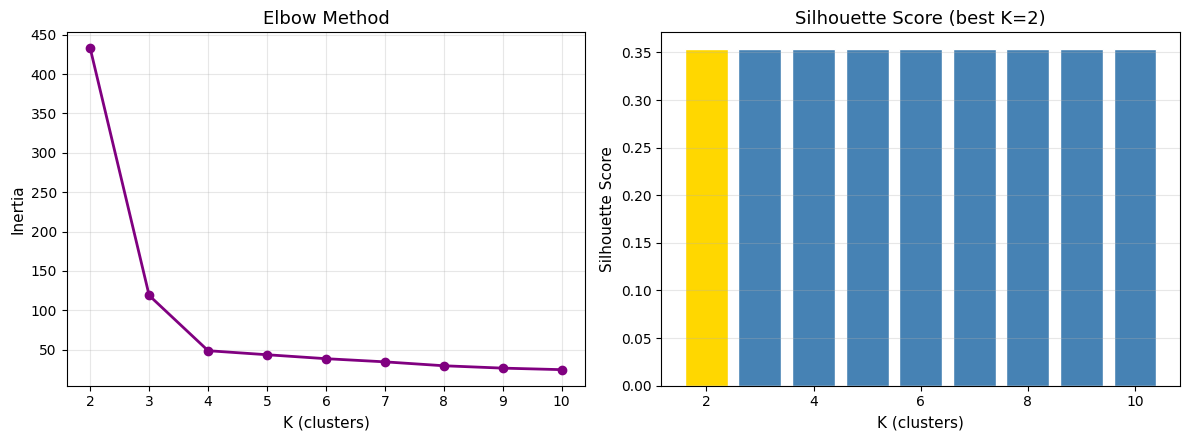


Elbow suggests: look around K=3-5
Silhouette says: best K = 2 (score=0.3534)


In [9]:
# ■■ Plot both ■■
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Elbow plot
ax1.plot(k_range, inertias, 'o-', color='purple', lw=2)
ax1.set_xlabel('K (clusters)', fontsize=11); ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13); ax1.grid(alpha=0.3)
# Silhouette plot
best_k = k_range[silhouettes.index(max(silhouettes))]
bars = ax2.bar(k_range, silhouettes, color=['gold' if k==best_k else 'steelblue'
for k in k_range], edgecolor='white')
ax2.set_xlabel('K (clusters)', fontsize=11); ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title(f'Silhouette Score (best K={best_k})', fontsize=13); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print(f'\nElbow suggests: look around K=3-5')
print(f'Silhouette says: best K = {best_k} (score={max(silhouettes):.4f})')

Visualising Clusters

Raw numbers tell you cluster assignments. Visualisation tells you what those clusters mean. Colour-coded scatter
plots and cluster profile charts are the most powerful tools for understanding what each group represents

After applying K-Means Clustering, the algorithm gives us cluster labels such as:

Customer 1 → Cluster 0

Customer 2 → Cluster 1

Customer 3 → Cluster 2


These numbers tell us which cluster a data point belongs to, but they do not explain what the cluster actually represents.

This is where visualisation becomes important.



Raw Numbers vs Visualisation

| Raw Numbers            | Visualisation                     |
| ---------------------- | --------------------------------- |
| Shows cluster IDs      | Shows cluster meaning             |
| Difficult to interpret | Easy to understand                |
| Tells "which cluster"  | Tells "why they belong together"  |
| Useful for computation | Useful for business understanding |


Cluster Visualisation Toolkit

Four ways to visualise and understand what your clusters mean:

In [10]:
# ■■ Cluster Visualisation Toolkit ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [11]:
# Use mall customer dataset (from Lab 7) or simulate here
np.random.seed(42)
n=200

age = np.concatenate(
        [
        np.random.normal(25,5,60),
        np.random.normal(45,8,80),
        np.random.normal(60,6,60)]
    )

income = np.concatenate(
    [np.random.normal(30,8,60),
     np.random.normal(60,12,80),
     np.random.normal(50,10,60)])


spending= np.concatenate(
    [np.random.normal(70,10,60),
     np.random.normal(50,15,80),
     np.random.normal(30,8,60)])

df = pd.DataFrame(
    {'Age':age,
     'Annual_Income':income,
     'Spending_Score':spending
      })

X = StandardScaler().fit_transform(df)

km = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = km.fit_predict(X)
colors = ['#3B82F6','#EF4444','#10B981']
cluster_names = {0:'Young Spenders', 1:'Mid-Income Balanced', 2:'Older Conservative'}

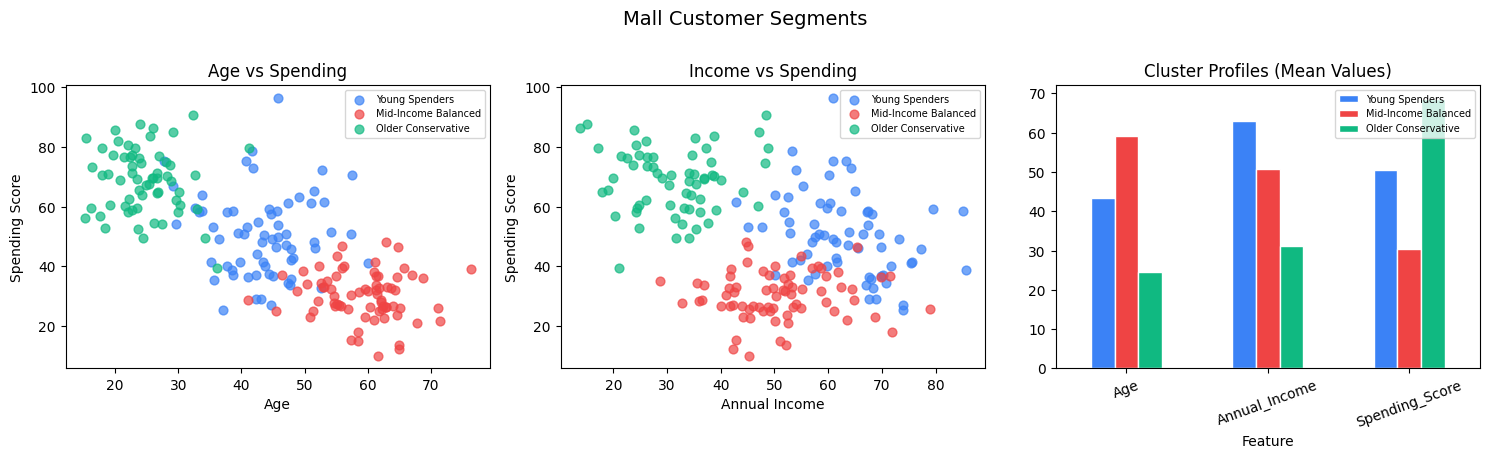

In [12]:
# ■■ Plot 1: Scatter — Age vs Spending ■■
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for c in range(3):
  mask = df['Cluster'] == c
  axes[0].scatter(df[mask]['Age'], df[mask]['Spending_Score'],
    c=colors[c], s=40, alpha=0.7, label=cluster_names[c])
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Spending Score')
axes[0].set_title('Age vs Spending'); axes[0].legend(fontsize=7)
# ■■ Plot 2: Scatter — Income vs Spending ■■
for c in range(3):
  mask = df['Cluster'] == c
  axes[1].scatter(df[mask]['Annual_Income'], df[mask]['Spending_Score'],
  c=colors[c], s=40, alpha=0.7, label=cluster_names[c])
axes[1].set_xlabel('Annual Income'); axes[1].set_ylabel('Spending Score')
axes[1].set_title('Income vs Spending'); axes[1].legend(fontsize=7)
# ■■ Plot 3: Cluster profiles (mean values per cluster) ■■
profiles = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()
profiles.index = [cluster_names[i] for i in profiles.index]
profiles.T.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('Cluster Profiles (Mean Values)')
axes[2].set_xlabel('Feature'); axes[2].legend(fontsize=7)
axes[2].tick_params(axis='x', rotation=20)
plt.suptitle('Mall Customer Segments', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

Correlation Matrix & Heatmap

Correlation Matrix — Understanding Relationships Between Features

Before applying Clustering, Regression, or any Machine Learning model, it is important to understand how the features are related to each other.

A Correlation Matrix helps us measure the relationship between every pair of columns in a dataset.

What is Correlation?

Correlation tells us:

"When one feature changes, how does another feature change?"

For example:

As income increases, spending may increase.

As stress increases, sleep may decrease.

Correlation helps identify these relationships.

Pearson Correlation Coefficient

The most commonly used correlation measure is the Pearson Correlation Coefficient.

Its value ranges from:

−1to+1

Where:

+1 → Perfect positive relationship

0 → No relationship

-1 → Perfect negative relationship

| Correlation Value | Relationship      | Meaning                                        | Example                          |
| ----------------- | ----------------- | ---------------------------------------------- | -------------------------------- |
| **+0.7 to +1.0**  | Strong Positive   | Both variables increase together               | Income ↑ and Spending ↑          |
| **+0.3 to +0.7**  | Moderate Positive | One generally increases as the other increases | Age ↑ and Experience ↑           |
| **-0.1 to +0.1**  | No Correlation    | No meaningful relationship                     | Shoe Size and IQ                 |
| **-0.3 to -0.7**  | Moderate Negative | One increases while the other decreases        | Stress ↑ and Sleep ↓             |
| **-0.7 to -1.0**  | Strong Negative   | Strong opposite movement                       | Temperature ↑ and Heating Bill ↓ |


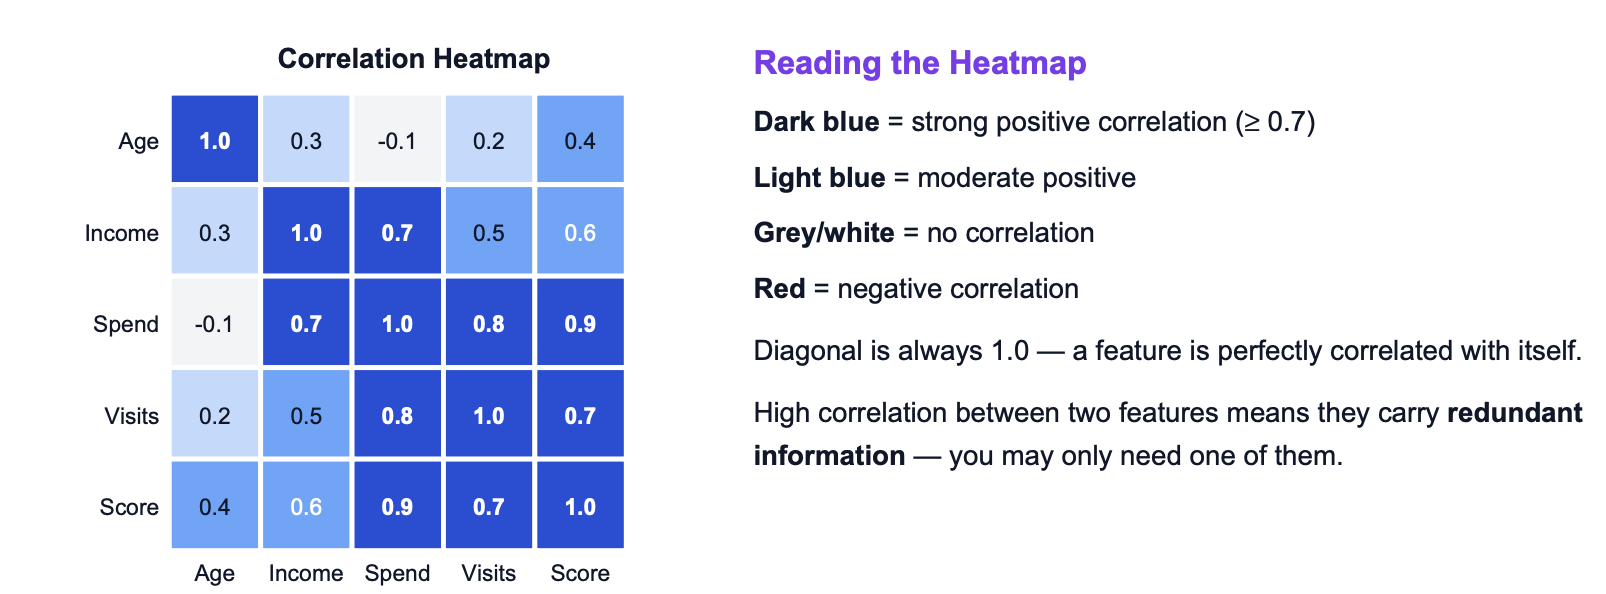

Correlation Matrix + Annotated Heatmap

In [13]:
# ■■ Correlation Matrix + Heatmap ■■
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
# Load or create a dataset
# df = pd.read_csv('diabetes.csv') # Using the 'df' created in the previous cells

In [14]:
# ■■ Correlation matrix (numbers) ■■
corr_matrix = df.corr(numeric_only=True) # Pearson by default
print('Correlation with Spending_Score:')
print(corr_matrix['Spending_Score'].sort_values(ascending=False).round(3))

Correlation with Spending_Score:
Spending_Score    1.000
Cluster           0.364
Annual_Income    -0.417
Age              -0.766
Name: Spending_Score, dtype: float64


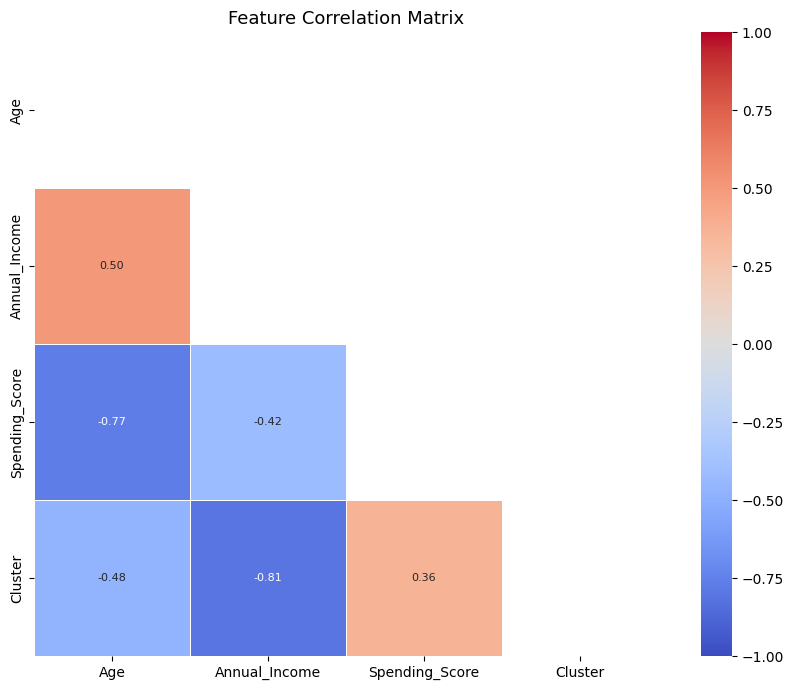

In [15]:
# ■■ Seaborn heatmap ■■
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # hide upper triangle
sns.heatmap(
corr_matrix,
annot=True, # show values in each cell
fmt='.2f', # 2 decimal places
cmap='coolwarm', # blue=positive, red=negative
mask=mask, # only show lower triangle
vmin=-1, vmax=1, # fix colour scale
             linewidths=0.5,
square=True,
annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()

Outlier Detection with Boxplots & IQR

An outlier is a data point that is unusually far from the rest. Outliers can be errors (data entry mistake), or genuine
extreme values (a millionaire in a survey). Either way, you need to detect and decide what to do with them before
modelling

The IQR Method

The Interquartile Range (IQR) is the range of the middle 50% of data. Anything beyond 1.5×IQR from the quartiles is
flagged as an outlier.

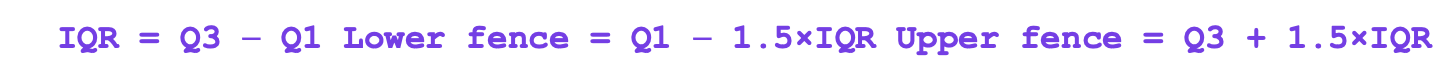

Options for Handling Outliers

| Option                       | When to Use                                                                | Example                                                |
| ---------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------ |
| **Remove**                   | When the value is clearly incorrect or impossible                          | Age = 300, Salary = -5000                              |
| **Cap / Clip (Winsorizing)** | When you want to reduce the effect of extreme values without deleting data | Replace Salary = ₹10,00,000 with the upper fence value |
| **Keep**                     | When the outlier is a real and important observation                       | Fraud transaction, elite athlete performance           |
| **Investigate**              | When the reason for the outlier is unknown                                 | Unusually high purchase amount                         |


 Boxplots, IQR Detection, and Outlier Handling

In [16]:
# ■■ Outlier Detection: Boxplots + IQR + Z-Score ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
#df = pd.read_csv('diabetes.csv') # Using the 'df' created in the previous cells

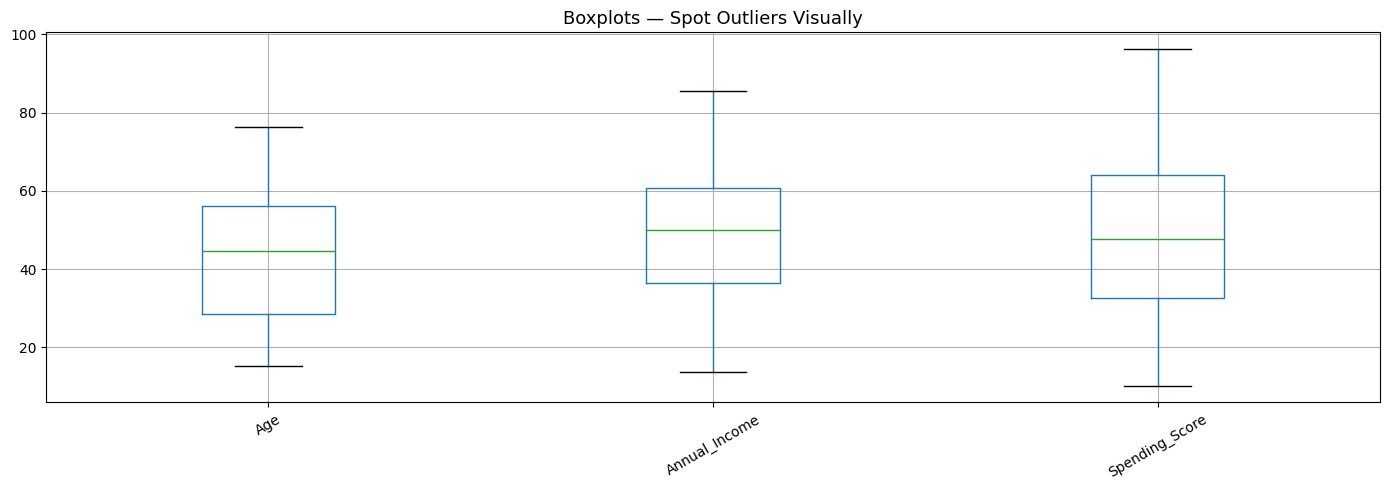

In [17]:
# ■■ Part 1: Boxplots for all features ■■
plt.figure(figsize=(14, 5))
df.drop('Cluster', axis=1).boxplot()
plt.title('Boxplots — Spot Outliers Visually', fontsize=13)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
# The dots beyond the whiskers = outliers

In [18]:
# ■■ Part 2: Quantify outliers with IQR method ■■
def find_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower) | (df[column] > upper)]
  return outliers, lower, upper
print(f'{'Column':25s} {'Outliers':>8} {'Lower':>8} {'Upper':>8}')
print('-' * 58)
for col in df.select_dtypes(include='number').columns:
  out, lo, hi = find_outliers(df, col)
  if len(out) > 0:
    print(f'{col:25s} {len(out):>8} {lo:>8.1f} {hi:>8.1f}')

Column                    Outliers    Lower    Upper
----------------------------------------------------------


In [19]:
# ■■ Part 3: Handle outliers — three strategies ■■
col = 'Annual_Income' # Has many outliers
# Strategy A: Remove rows with outliers
_, lo, hi = find_outliers(df, col)
df_clean = df[(df[col] >= lo) & (df[col] <= hi)]
print(f'\nRows before: {len(df)}, after removing outliers: {len(df_clean)}')


Rows before: 200, after removing outliers: 200


In [20]:
# Strategy B: Cap/Clip to fence values (keeps all rows)
df_capped = df.copy()
df_capped[col] = df_capped[col].clip(lower=lo, upper=hi)
print(f'Max Insulin before: {df[col].max():.0f}, after capping: {df_capped[col].max():.0f}')

Max Insulin before: 86, after capping: 86


In [21]:
S# Strategy C: Z-score method (flag anything > 3 std deviations)
from scipy import stats
z_scores = np.abs(stats.zscore(df.select_dtypes(include='number')))
outlier_rows = (z_scores > 3).any(axis=1).sum()
print(f'Rows with any z-score > 3: {outlier_rows}')

Rows with any z-score > 3: 0
